In [139]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [140]:
#import datbase/data

In [141]:
conn = sqlite3.connect("customer_churn.db")
sql_query = """
               SELECT name
               FROM sqlite_master
               WHERE type = 'table'
               """
tables = pd.read_sql(sql_query, conn)

#create datframe for each table
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"created datframe : df_{table_name}")



created datframe : df_db_customer
created datframe : df_db_subscription
created datframe : df_db_support


In [142]:
# print table names and column names
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name : {table_name}")
    #get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns:")
    print(columns['name'].tolist())

  #close connection
    conn.close


Table Name : db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name : db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name : db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [143]:
#data cleaning

In [144]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [145]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [146]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [147]:
# a. rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'})

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [148]:
df_db_customer

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [149]:
# b. drop columns - interest and pincode

df_db_customer.drop(df_db_customer.columns[-2:] , axis=1)

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [150]:
df_db_customer.columns[6:]

Index(['interests', 'pincode'], dtype='object')

In [151]:
df_db_customer.drop(columns = ['interests' , 'pincode'])

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [152]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [153]:
# c. change data type - dob

pd.to_datetime(df_db_customer['dob'])

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[ns]

In [154]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [155]:
# c. data standardization - gender

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [156]:
df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})


0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [157]:
# e. fix missing values - country
# *True means value are null

df_db_customer['country'].isna()


0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [158]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [159]:
df_db_customer['country'].fillna('Nahi Pata')

0         India
1         India
2         India
3         India
4         India
5     Nahi Pata
6         India
7         India
8     Nahi Pata
9         Nepal
10        India
11        India
12    Nahi Pata
13        India
14        India
15        India
16        India
17        India
18        India
19        India
20        India
Name: country, dtype: object

In [160]:
df_db_customer[['country' , 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [161]:
#country and state - unique value pair

df_db_customer.dropna(subset=['country']).set_index('state')

,customerid,name,country,gender,dob,interests,pincode
state,,,,,,,
Maharashtra,0002-ORFBO,keshav,India,Male,1982-04-12,travel,None
Karnataka,0003-MKNFE,raghav,India,Male,1995-11-23,None,None
Delhi,0004-TLHLJ,lalita,India,Female,1978-02-15,movie,None
Nagaland,0011-IGKFF,mohan,India,Male,2001-08-30,None,None
Delhi,0013-EXCHZ,mira,India,Female,1990-05-05,drama,None
Meghalaya,0013-SMEOE,mina,India,Female,1976-09-21,None,None
Rajasthan,0014-BMAQU,madan,India,Male,1999-03-14,None,None
Kathmandu,0016-QLJIS,arjun,Nepal,Male,1993-10-29,None,None
Maharashtra,0017-DINOC,shiva,India,Men,1997-01-22,None,None


In [162]:
df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [163]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [164]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [165]:
df_db_customer[['country' , 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [166]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [167]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [168]:
date_col = ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_db_subscription[date_col].apply(pd.to_datetime)

,subscription_start_date,renewal_date,cancellation_date
0,2021-03-15,2025-03-15,NaT
1,2020-08-01,2024-08-01,2024-09-10
2,2022-11-20,2025-11-20,NaT
3,2019-05-10,2025-05-10,NaT
4,2023-01-05,2024-01-05,2024-02-28
5,2022-06-18,2025-06-18,NaT
6,2021-09-30,2024-09-30,2024-11-15
7,2020-02-14,2025-02-14,NaT
8,2023-07-22,2024-07-22,NaT
9,2022-04-03,2025-04-03,NaT


In [169]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [170]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [171]:
df_db_support.drop(columns=['col_1' , 'comment'], inplace=True)

In [172]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [173]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [174]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [175]:
# 3. Feature Engineering and Data Analysis
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34


In [176]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [177]:
np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [178]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [179]:
df_db_subscription.merge(df_db_customer , on='customerid' , how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,drama,None
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22,0,durga,None,Delhi,Women,1988-12-10,None,None
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,None,None
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,None,None
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34,0,maya,None,Kathmandu,Women,1985-07-07,None,None
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29,None,None


In [180]:
df_db_subscription.merge(df_db_support , on='customerid' , how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12,0,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34,0,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8,0,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22,0,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5,0,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34,0,NaT,NaN,NaN


In [181]:
df=(df_db_subscription
    .merge(df_db_customer, on ='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

In [182]:
df.shape

(23, 22)

In [183]:
df_db_subscription.shape

(21, 12)

In [184]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,movie,None,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,None,None,NaT,NaN,NaN


In [185]:
df_db_subscription['customerid'].unique()

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF',
       '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU',
       '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW',
       '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK',
       '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL',
       '0023-UYUPN'], dtype=object)

In [186]:
df_db_subscription['customerid'].nunique()

21

In [187]:
df_db_customer['customerid'].nunique()

21

In [188]:
df_db_support['customerid'].nunique()

7

In [189]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [190]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [191]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [192]:
df_db_support['compaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [193]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

,customerid,complaint_date,escalations,csat_score,compaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [194]:
df_db_support['customerid'].size

9

In [195]:
df.shape

(23, 22)

In [196]:
df.to_csv('exported_churn_data.csv', index=False)

In [197]:
#data analysis

In [198]:
#churn score

In [199]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score'],
      dtype='object')

In [200]:
df['churn_flag'].mean()*100

np.float64(34.78260869565217)

In [201]:
churn_rate = df['churn_flag'].mean()*100

print("churn_rate=",round(churn_rate,2),"%")

churn_rate= 34.78 %


In [202]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print("retention_rate=",round(retention_rate,2),"%")

retention_rate= 65.22 %


In [203]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,movie,None,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,None,None,NaT,NaN,NaN


In [204]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,name,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,N,60.0


In [205]:
# 3. churn by plan type
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.666667
Premium     0.250000
Standard    0.222222
Name: churn_flag, dtype: float64

In [206]:
df.groupby('plan_type')['churn_flag'].mean().reset_index()

,plan_type,churn_flag
0,Basic,0.666667
1,Premium,0.250000
2,Standard,0.222222


In [207]:
df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')

,plan_type,churn_rate_pct
0,Basic,66.67
1,Premium,25.00
2,Standard,22.22


In [208]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index())
print(churn_by_plan)

  plan_type  churn_flag
0     Basic       66.67
1   Premium       25.00
2  Standard       22.22


In [209]:
# 4 a. churn by state  + sum(revenue) & count of users -- homework**
# 4 b. churn by subscription type + sum(revenue) & count of users --homwork**


In [210]:
#ARPU - Avg revenue per user

In [211]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score'],
      dtype='object')

In [212]:
df['monthly_charges'].mean()

np.float64(18.511739130434783)

In [213]:
arpu = df['monthly_charges'].mean()
print("ARPU=",round(arpu,2))

ARPU= 18.51


In [214]:
# 6. Avg customer tenure
# count of days users has used our service : cancellation date else current date
pd.Timestamp.today()

Timestamp('2026-07-19 10:08:16.228736')

In [215]:
# Ensure both columns are converted to datetime
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')

# Get today's date
today = pd.Timestamp.today()

# Compute tenure_days safely
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

# Calculate average tenure
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) =", round(avg_tenure, 0))

Avg Tenure (Days) = 1449.0


In [216]:
# Revenue at risk - revenue last from churned users
round(df.loc[df['churn_flag']==1, 'monthly_charges'].sum(),2)

np.float64(103.92)

In [217]:
# 8. Escalation Rate
# df['escalation'=='Y']
df['escalations'].unique()

array([nan, 'N', 'Y'], dtype=object)

In [218]:
Escalation_Rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate",round(Escalation_Rate,2),"%")

Escalation Rate 21.74 %


In [219]:
# 10. Correlation Escalation vs churn
df[['escalations' , 'churn_flag' , 'customerid']].dropna()

,escalations,churn_flag,customerid
1,N,1,0003-MKNFE
2,Y,1,0003-MKNFE
5,Y,1,0013-EXCHZ
6,N,0,0013-MHZWF
7,N,1,0013-SMEOE
12,Y,1,0017-IUDMW
14,Y,1,0019-EFAEP
19,Y,1,0022-TCJCI
20,N,1,0022-TCJCI


In [220]:
df['escalations'] = np.where(df['escalations']=='Y',1,0)
corr_df = df[['escalations' , 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("correlation between escalation vs churn is = " , round(correlation,2))

correlation between escalation vs churn is =  0.72


In [221]:
# 11. churn risk - create a column using existing col
df['churn_score'].head()

0    12
1    91
2    91
3    34
4     8
Name: churn_score, dtype: int64

In [222]:
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 50)
]

choices = ['low','med','high']
df['churn_risk'] = np.select(conditions , choices , default='unknown')

In [223]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,travel,None,NaT,0,NaN,1952.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,None,None,2024-08-28,0,60.0,1501.0,high
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,None,None,2024-08-28,1,10.0,1501.0,high
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,movie,None,NaT,0,NaN,1337.0,low
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,None,None,NaT,0,NaN,2627.0,low


In [224]:
df[['churn_risk' , 'churn_score']].tail()

,churn_risk,churn_score
18,low,27
19,high,99
20,high,99
21,low,7
22,low,47


In [225]:
# visualization using Matplotlib

In [226]:
df_visual = df.copy()

In [227]:
df_visual.shape

(23, 24)

In [228]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score', 'tenure_days',
       'churn_risk'],
      dtype='object')

In [229]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_date'].dt.to_period('M')

0         NaT
1     2024-09
2     2024-09
3         NaT
4         NaT
5     2024-02
6         NaT
7     2024-11
8         NaT
9         NaT
10        NaT
11        NaT
12    2024-05
13        NaT
14    2024-10
15        NaT
16        NaT
17        NaT
18        NaT
19    2024-09
20    2024-09
21        NaT
22        NaT
Name: cancellation_date, dtype: period[M]

In [230]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

cancellation_month
2024-02    1
2024-05    1
2024-09    4
2024-10    1
2024-11    1
Freq: M, dtype: int64

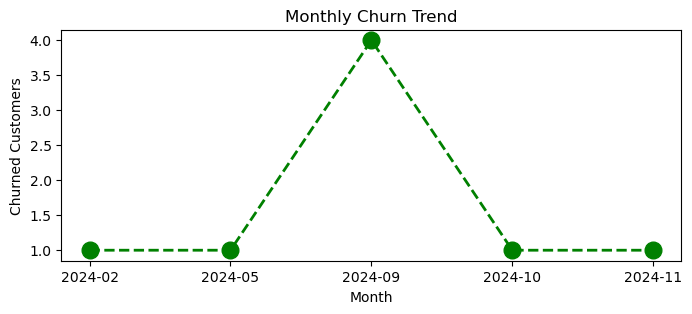

In [231]:
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='green',marker='o',linestyle='dashed',linewidth=2,markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [232]:
# 4.2 Churn by plan type
df_visual.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.666667
Premium     0.250000
Standard    0.222222
Name: churn_flag, dtype: float64

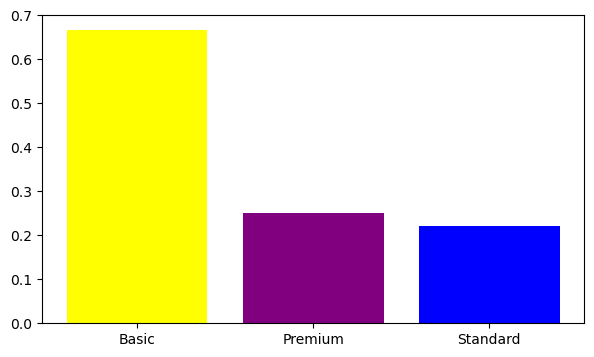

In [233]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
color = ['yellow','purple','blue']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values,color=color)
plt.show()

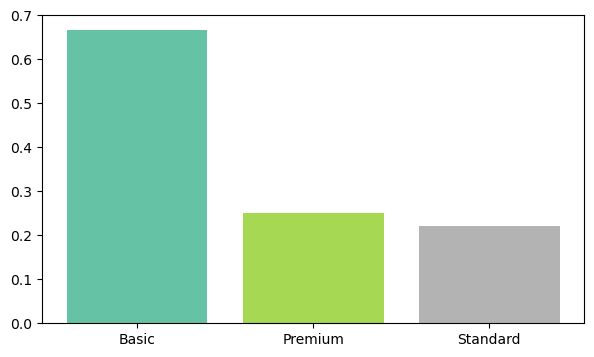

In [234]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
color = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values,color=color)
plt.show()

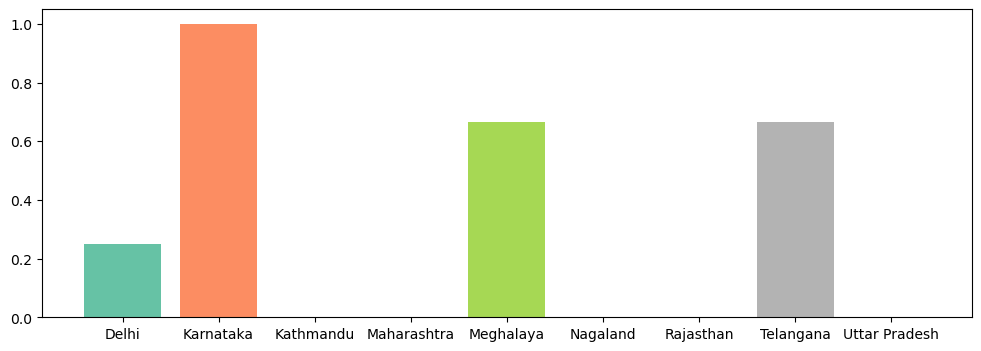

In [235]:
#churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
color = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values,color=color)
plt.show()

In [236]:
# Visualization using Seaborn
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score', 'tenure_days',
       'churn_risk', 'cancellation_month'],
      dtype='object')

In [237]:
import warnings
warnings.filterwarnings("ignore")

In [238]:
#incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[ ['plan_type', 'contract_type','churn_flag','escalations','churn_risk']]

categorical_cols = ['plan_type','contract_type','churn_risk']

for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

<Axes: >

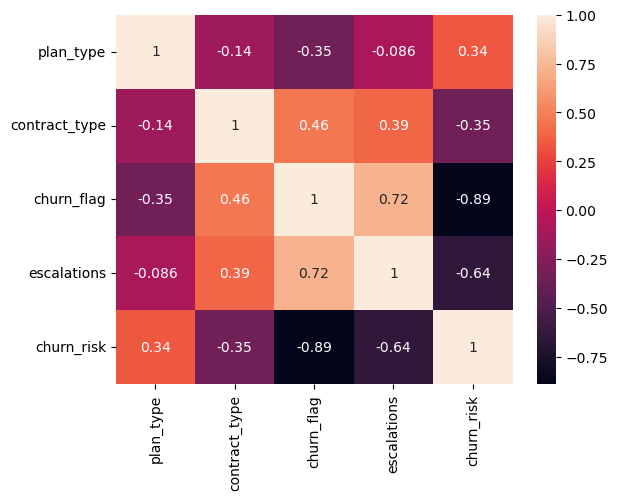

In [239]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),  annot=True)

In [240]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes


In [241]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Premium,Annual,91,1,high,1
3,Basic,Monthly,34,0,low,0
4,Premium,Annual,8,0,low,0


In [242]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,2,1,91,1,2,1
3,0,0,34,0,0,0
4,2,1,8,0,0,0


<Axes: >

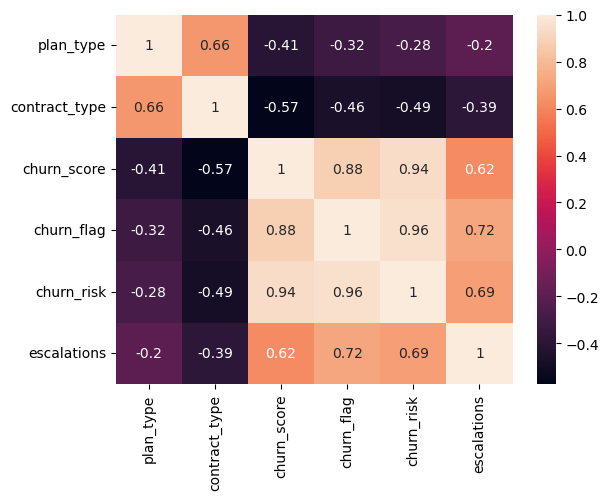

In [243]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

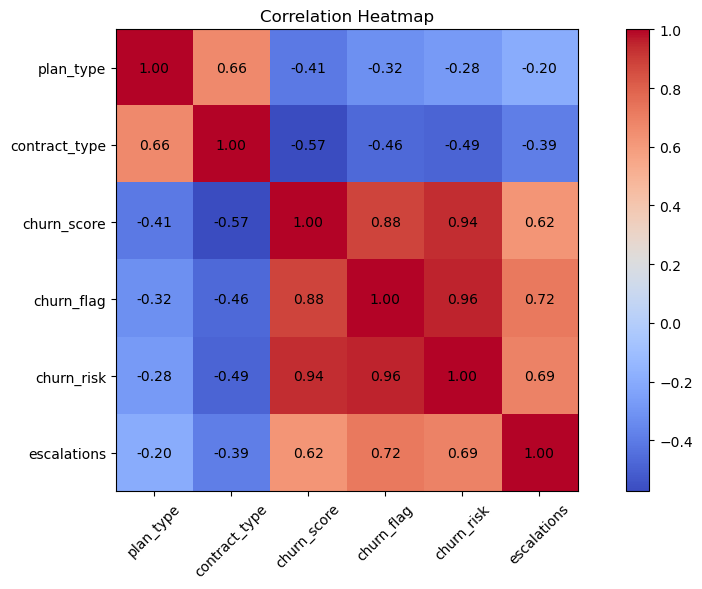

In [244]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

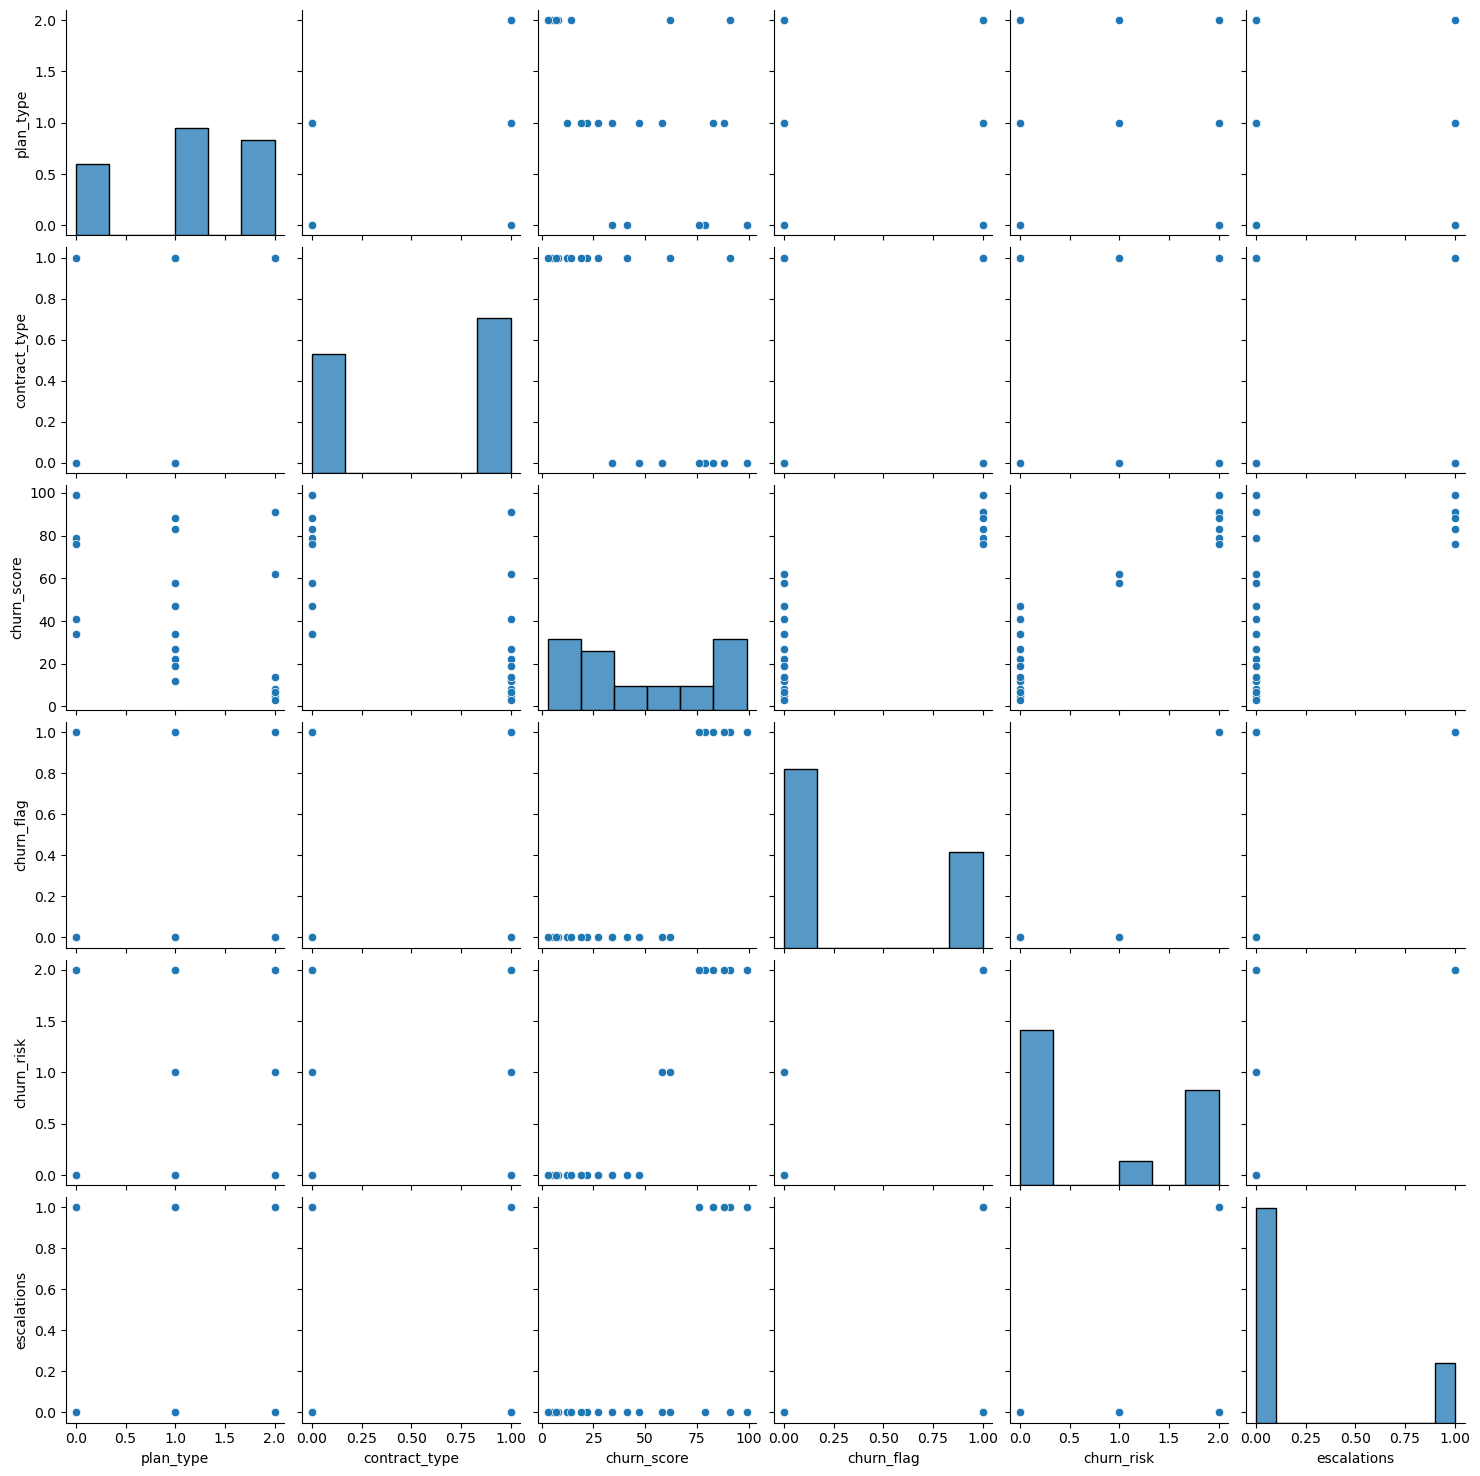

In [245]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

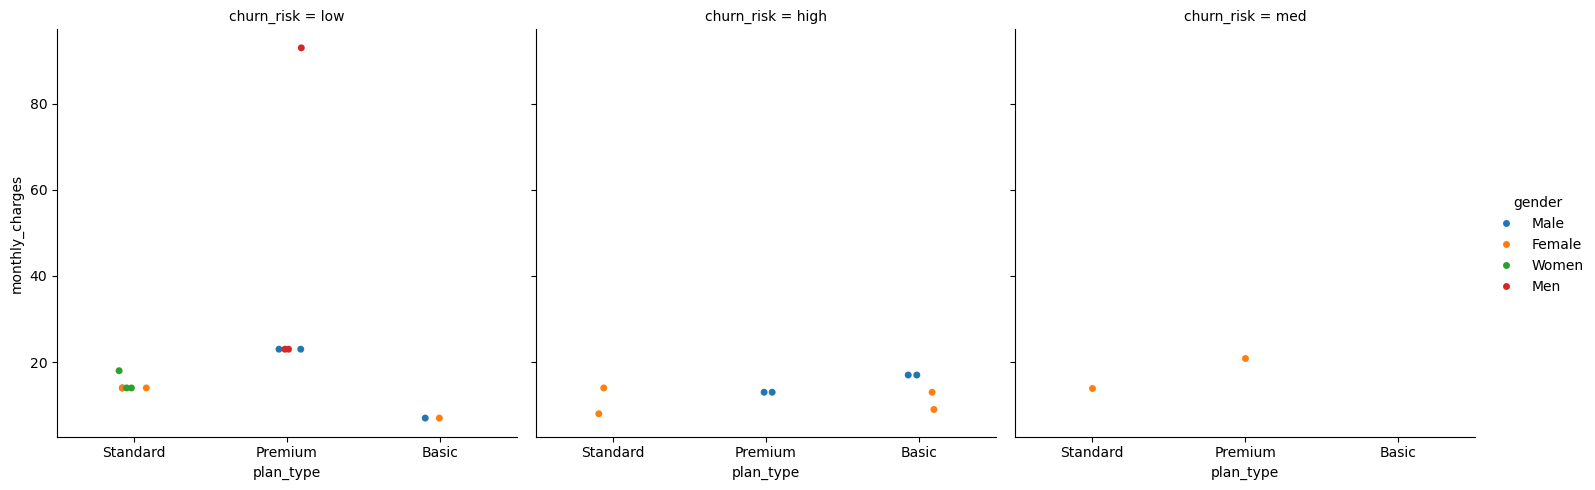

In [247]:
#catplot/Facegrid plot - multi dim comparision

sns.catplot(data=df_visual,
        x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')        

In [248]:
#pivot table

In [249]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.666667
Premium,0.250000
Standard,0.222222


In [250]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.666667,5,69.94
Premium,0.250000,7,231.92
Standard,0.222222,9,123.91


In [252]:
# Project Completed Here.)

In [253]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

print("Cretaed Table successfully!")

Cretaed Table successfully!


In [254]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [255]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [256]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [257]:
# always close the conn with db once the task is over
conn.close()